Calculating SHAP values...


c:\Users\hp\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


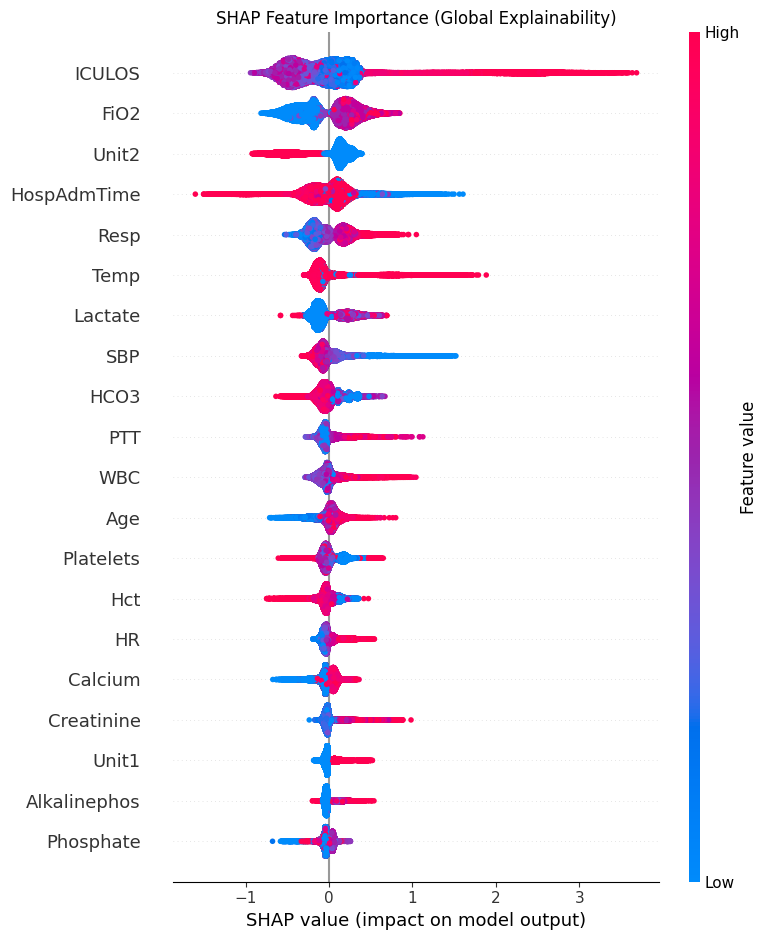

In [1]:
import pandas as pd
import pickle
import shap
import matplotlib.pyplot as plt

# 1. Load the pre-trained LightGBM model
with open('../models/sepsis_model.pkl', 'rb') as f:
    lgb_model = pickle.load(f)

# 2. Load the test data
X_test = pd.read_csv('../data/processed/X_test.csv')

# 3. Calculate SHAP values
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# 4. Generate SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance (Global Explainability)")
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values, X_test, show=False)
plt.tight_layout()
plt.show()